In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load CSV
df = pd.read_csv(r"C:\Users\KIIT0001\OneDrive\Desktop\attendence_project\data\raw\attendance_details.csv")

# Preview
df.head()

,attendance_id,student_id,course_id,attendance_date,status,recorded_at
0,1,12648,1960,2026-03-01,Present,2026-04-18 17:23:03
1,2,25218,1670,2026-03-02,Absent,2026-04-18 17:23:03
2,3,42995,1496,2026-03-04,Present,2026-04-18 17:23:03
3,4,46889,575,2026-03-10,Present,2026-04-18 17:23:03
4,5,12673,858,2026-03-08,Present,2026-04-18 17:23:03


In [3]:
print("Total Records:", len(df))
print("Present Count:", len(df[df["status"] == "Present"]))
print("Absent Count:", len(df[df["status"] == "Absent"]))

Total Records: 15000
Present Count: 12055
Absent Count: 2945


In [4]:
#Course-Wise Attendance
course_attendance = df.groupby("course_id")["status"].value_counts().unstack().fillna(0)

course_attendance

status,Absent,Present
course_id,,
513,21,130
531,25,106
559,45,133
573,45,110
575,26,105
...,...,...
1951,25,125
1960,27,140
1974,31,115


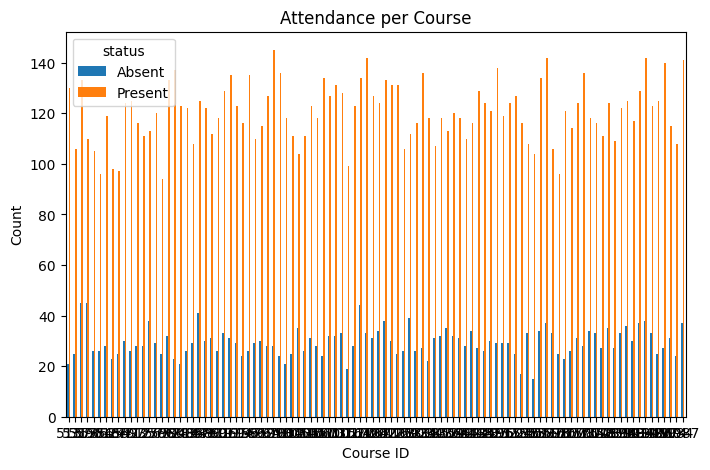

In [5]:
course_attendance.plot(kind="bar", figsize=(8,5))

plt.title("Attendance per Course")
plt.xlabel("Course ID")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [6]:
student_attendance = df.groupby("student_id")["status"].value_counts().unstack().fillna(0)

student_attendance["attendance_%"] = (
    student_attendance["Present"] /
    (student_attendance["Present"] + student_attendance["Absent"])
) * 100

student_attendance

status,Absent,Present,attendance_%
student_id,,,
100,0.0,3.0,100.0
131,1.0,0.0,0.0
142,0.0,2.0,100.0
159,1.0,0.0,0.0
165,0.0,2.0,100.0
...,...,...,...
49969,0.0,2.0,100.0
49975,0.0,1.0,100.0
49986,1.0,1.0,50.0


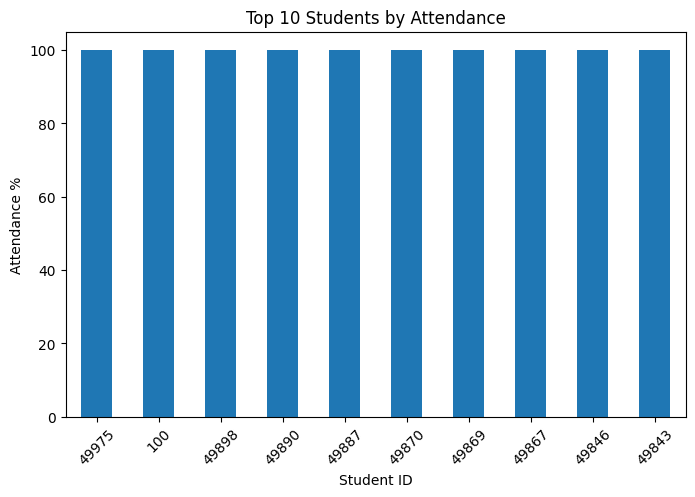

In [8]:
#Top 10 students by attendence%
top_students = student_attendance.sort_values("attendance_%", ascending=False).head(10)

top_students["attendance_%"].plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Students by Attendance")
plt.xlabel("Student ID")
plt.ylabel("Attendance %")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Highest attendance course
top_course = df[df["status"] == "Present"].groupby("course_id").size().idxmax()

# Most absent student
top_absent_student = df[df["status"] == "Absent"].groupby("student_id").size().idxmax()

print("Course with highest attendance:", top_course)
print("Most frequently absent student:", top_absent_student)

Course with highest attendance: 973
Most frequently absent student: 24119
